# ASSIGNMENT - 2A

**Submitted by:** Laba Deka  
**ID:** N13134608  
**Email:** lkd8786@nyu.edu  
**NetId:** lkd8786  


The codes below implement the two algorithms as given in the assignment. Will be explaining with comments and markdown wherever possible on the implementation.


In [1]:
from datasets import load_dataset
ds = load_dataset("pantelism/cats-vs-dogs")

c:\Users\labak\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This code snippet displays the image at index 2000 from the training set of the "Cats vs. Dogs" dataset using Matplotlib. It removes the axis for a cleaner view and then prints the corresponding label (0 for cat or 1 for dog) of the displayed image

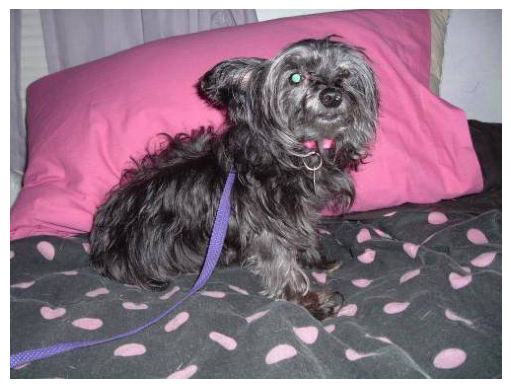

1


In [2]:
import matplotlib.pyplot as plt

# Directly use the image object for display
image = ds['train'][2000]['image']  # Assuming 'image' is the key for the image data
plt.imshow(image)
plt.axis('off')
plt.show()
print(ds['train'][2000]['label'] )


This code snippet splits the "Cats vs. Dogs" dataset into three parts: 50% for training, and then further divides the remaining 50% into 25% for validation and 25% for testing. It uses shuffling to ensure random distribution of samples across the split

In [3]:
# Split the dataset (50% train, 25% validation, 25% test)
train_val_split = ds['train'].train_test_split(test_size=0.5, shuffle=True)
train_ds = train_val_split['train']
temp_ds = train_val_split['test']

# Now split the temporary dataset (25% validation, 25% test)
val_test_split = temp_ds.train_test_split(test_size=0.5, shuffle=True)
val_ds = val_test_split['train']  # 25% validation
test_ds = val_test_split['test']  # 25% test


This code defines a function to count the occurrences of each label (0 and 1) in a dataset. It then applies this function to the training, validation, and test datasets, and prints the label counts for each. This helps assess the class distribution in the datasets

In [4]:
# Function to count labels in a dataset
def count_labels(dataset):
    return {label: sum(1 for item in dataset if item['label'] == label) for label in (0, 1)}

# Count labels in all datasets
train_counts, val_counts, test_counts = (
    count_labels(ds) for ds in (train_ds, val_ds, test_ds)
)

# Print the results
print("Training dataset label counts:", train_counts)
print("Validation dataset label counts:", val_counts)
print("Test dataset label counts:", test_counts)


Training dataset label counts: {0: 993, 1: 1007}
Validation dataset label counts: {0: 482, 1: 518}
Test dataset label counts: {0: 525, 1: 475}


This code performs the following steps:

#### Load Dataset: It loads the "Cats vs. Dogs" dataset and samples a smaller subset for faster processing.
#### Data Preparation: It preprocesses the images and splits the dataset into training and validation sets.
####  Model Creation: A pre-trained VGG16 model is loaded, customized with additional layers, and compiled.
#### Training: The model is trained on the training dataset for a specified number of epochs.
####  Prediction: The model makes predictions on a subset of images, displaying the predicted class and probabilities.
####  Save Model: Finally, the trained model is saved for future use

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4000
    })
})


Map: 100%|██████████| 20/20 [00:11<00:00,  1.69 examples/s]


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,560,769 (105.14 MB)

 Trainable params: 12,846,081 (49.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/3
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5675 - loss: 4.7395 - val_accuracy: 0.6500 - val_loss: 4.0903
Epoch 2/3
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5969 - loss: 2.8836 - val_accuracy: 0.3500 - val_loss: 3.9576
Epoch 3/3
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7174 - loss: 1.1473 - val_accuracy: 0.6500 - val_loss: 1.1646
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


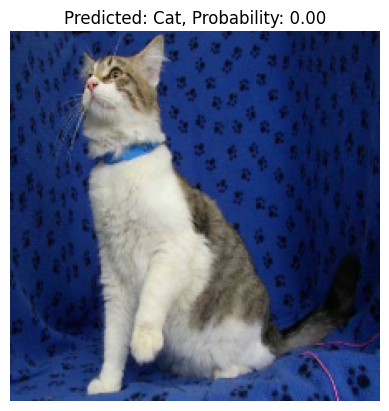

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


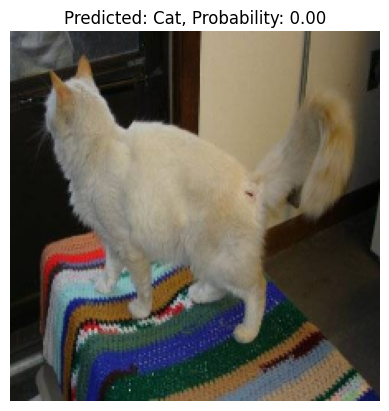

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


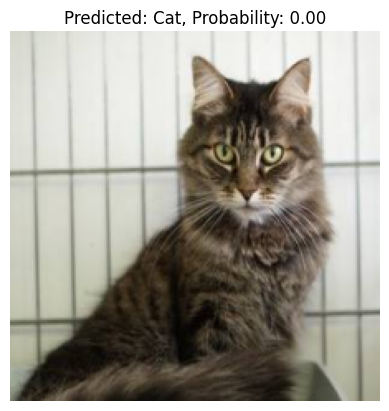

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


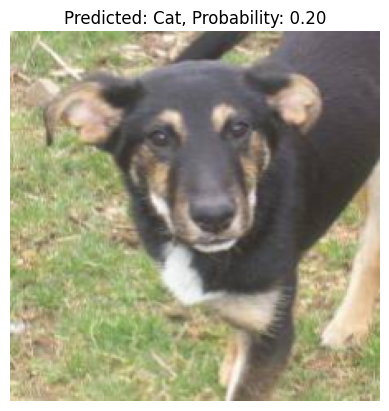

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


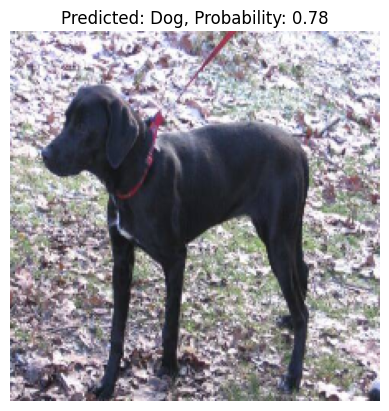

In [7]:
import tensorflow as tf
from datasets import load_dataset
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# Step 1: Load the dataset
ds = load_dataset("pantelism/cats-vs-dogs")

# Check available splits
print(ds)

# Sample a smaller subset
n_samples = 100  # Number of samples to keep
train_subset = ds['train'].shuffle(seed=42).select(range(n_samples))

# Split the training subset into training and validation sets
train_val_split = train_subset.train_test_split(test_size=0.2, shuffle=True)  # 80% train, 20% validation
train_ds = train_val_split['train']
val_ds = train_val_split['test']

# Step 2: Preprocess the images
def preprocess_image(image):
    image = tf.image.resize(image, (224, 224))
    return image / 255.0  # Normalize pixel values

# Convert dataset to TensorFlow Dataset
def format_dataset(dataset):
    def process_example(example):
        image = preprocess_image(example['image'])
        label = example['label']
        return {'image': image, 'label': label}  # Return as a dictionary
    
    # Map the processing function
    dataset = dataset.map(process_example, remove_columns=['image', 'label'])
    
    return dataset

# Apply formatting to each dataset
train_ds = format_dataset(train_ds)
val_ds = format_dataset(val_ds)

# Convert to TensorFlow Dataset format
train_ds = tf.data.Dataset.from_tensor_slices((train_ds['image'], train_ds['label']))
val_ds = tf.data.Dataset.from_tensor_slices((val_ds['image'], val_ds['label']))

# Step 3: Load Pretrained Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers for the classification task
x = layers.Flatten()(base_model.output)
x = layers.Dense(512, activation='relu')(x)
predictions = layers.Dense(1, activation='sigmoid')(x)

# Create the new model
model = models.Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model architecture
model.summary()

# Step 4: Train the model
EPOCHS = 3
BATCH_SIZE = 16  # Set a smaller batch size

# Use the TensorFlow Dataset API to create batched datasets
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Train the model
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# Step 5: Make Predictions on the test set
# If there is no test set, use part of the training set for testing
test_subset = ds['train'].shuffle(seed=42).select(range(5))  # Randomly select 5 test images
for example in test_subset:
    img = preprocess_image(example['image'])
    img = tf.expand_dims(img, axis=0)

    # Make predictions
    predictions = model.predict(img)
    predicted_class = 'Dog' if predictions[0] >= 0.5 else 'Cat'
    
    # Display the image and prediction
    plt.imshow(tf.squeeze(img, axis=0))
    plt.title(f'Predicted: {predicted_class}, Probability: {predictions[0][0]:.2f}')
    plt.axis('off')
    plt.show()

# Step 6: Save the model
model.save('cats_vs_dogs_model_2.h5')  # Save the model as a .h5 file


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

INTEGRATED GRADIENTS

In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def compute_gradients(images, target_class_idx):
    """Compute the gradients of the model's predictions with respect to the input images."""
    with tf.GradientTape() as tape:
        tape.watch(images)
        logits = model(images)
        probs = tf.nn.softmax(logits, axis=-1)[:, target_class_idx]
    return tape.gradient(probs, images)


In [31]:
def interpolate_images(baseline, image, alphas):
    """Interpolate images between baseline and the input image."""
    alphas_x = alphas[:, tf.newaxis, tf.newaxis, tf.newaxis]
    baseline_x = tf.expand_dims(baseline, axis=0)
    input_x = tf.expand_dims(image, axis=0)
    delta = input_x - baseline_x
    images = baseline_x + alphas_x * delta
    return images



### Integrated Gradients for Model Interpretability

This code implements the Integrated Gradients method to attribute the model's predictions to the input image, allowing for interpretability in deep learning models.

#### Function: `integrated_gradients`

**Purpose**: Computes the integrated gradients, which quantify the contribution of each feature in the input image to the model's prediction.

**Parameters**:
- **`model`**: The trained Keras model for which to compute attributions.
- **`baseline`**: A baseline input (typically a black image) to compare against.
- **`image`**: The input image for which attributions are calculated.
- **`target_class`**: The specific class for which the attributions are computed.
- **`num_steps`**: Number of interpolation steps between the baseline and the input image.

#### Steps in Integrated Gradients:
1. **Interpolation**: Generates a set of interpolated images between the baseline and the target image using a series of alpha values.
2. **Gradient Calculation**: Computes gradients of the model's predictions with respect to the interpolated images.
3. **Attribution Calculation**: The average gradients are scaled by the difference between the input image and the baseline to obtain the attributions.


#### Output:
Returns the attributions as a NumPy array. The visualization shows the original image alongside the computed attributions, highlighting the features that contribute most to the model's prediction.


#### Mathematical Definition:
The integrated gradients for an input \( \mathbf{x} \) with respect to a baseline \( \mathbf{x'} \) can be expressed as:

\[
\text{IG}(\mathbf{x}) = (\mathbf{x} - \mathbf{x'}) \cdot \int_0^1 \nabla f(\mathbf{x'} + \alpha (\mathbf{x} - \mathbf{x'})) \, d\alpha
\]

where:
- \( f \) is the model's output,
- \( \nabla f \) is the gradient of \( f \) with respect to the input,
- \( \alpha \) is a scalar that varies from 0 to 1.


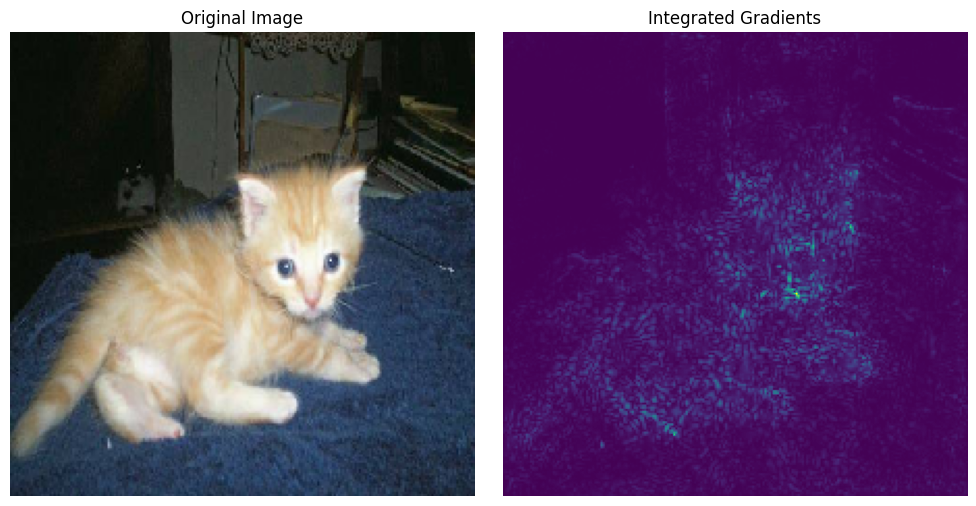

In [2]:
import tensorflow as tf
import numpy as np
import keras
import matplotlib.pyplot as plt

def compute_integrated_gradients(model, baseline_image, input_image, target_class_index, num_steps=50):
    """
    Compute the integrated gradients for a given input image.
    
    Parameters:
    model (tf.keras.Model): The pre-trained model to explain.
    baseline_image (np.ndarray): The baseline image (typically a black image).
    input_image (np.ndarray): The input image for which to compute attributions.
    target_class_index (int): The index of the target class for attribution.
    num_steps (int): Number of interpolation steps for gradient approximation.
    
    Returns:
    np.ndarray: The computed attributions for the input image.
    """
    # Convert baseline and input images to TensorFlow tensors
    baseline_image = tf.convert_to_tensor(baseline_image, dtype=tf.float32)
    input_image = tf.convert_to_tensor(input_image, dtype=tf.float32)

    # Generate a series of interpolated images between the baseline and input image
    alphas = tf.linspace(0.0, 1.0, num_steps + 1)
    alphas = tf.reshape(alphas, (num_steps + 1, 1, 1, 1))
    delta = input_image - baseline_image  # Difference between input and baseline
    interpolated_images = baseline_image + alphas * delta  # Create interpolated images

    # Calculate gradients of the model's predictions with respect to interpolated images
    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)  # Track the gradients
        predictions = model(interpolated_images)  # Get model predictions
        if target_class_index is not None:
            predictions = predictions[:, target_class_index]  # Focus on the target class

    gradients = tape.gradient(predictions, interpolated_images)  # Compute gradients

    # Calculate the average gradients to approximate the integral
    integrated_gradients = tf.reduce_mean(gradients, axis=0)

    # Scale the attributions based on the difference from the baseline
    attributions = delta * integrated_gradients
    return attributions.numpy()  # Return attributions as a NumPy array

# Load a sample image and resize it to (224, 224) for the model
sample_image_path = r'cat.1999.jpg'
sample_image = keras.utils.load_img(sample_image_path, target_size=(224, 224))  # Resize image
sample_image_array = keras.utils.img_to_array(sample_image)  # Convert to array format
sample_image_array = np.expand_dims(sample_image_array, axis=0) / 255.0  # Normalize to [0, 1]

# Create a baseline image (black image) of the same shape as the input
baseline_image = np.zeros_like(sample_image_array)

# Load the pre-trained Keras model from the .h5 file
trained_model = tf.keras.models.load_model('cats_vs_dogs_model_2.h5')

# Compute Integrated Gradients for the specified target class (0 for 'cat')
attributions = compute_integrated_gradients(trained_model, baseline_image, sample_image_array, target_class_index=0)

# Visualize the original image and the computed attributions
plt.figure(figsize=(10, 5))

# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(sample_image_array[0])  # Show the original image
plt.title('Original Image')
plt.axis('off')  # Hide axes for clarity

# Display the computed attributions as a heatmap
plt.subplot(1, 2, 2)
plt.imshow(np.sum(np.abs(attributions[0]), axis=-1), cmap='viridis')  # Visualize the absolute attributions
plt.title('Integrated Gradients')
plt.axis('off')  # Hide axes for clarity

plt.tight_layout()  # Adjust layout for better visibility
plt.show()  # Display the figures


In [3]:
model2 = tf.keras.models.load_model('cats_vs_dogs_model_2.h5')
for layer in model2.layers:
    print(layer.name)


input_layer_6
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool
flatten_6
dense_12
dense_13


GRAD-CAM


### Summary of the Grad-CAM Code

This code implements the Grad-CAM (Gradient-weighted Class Activation Mapping) technique to visualize the important regions in an image that contribute to a model's predictions.

1. **Image Preprocessing**:
   - The function `get_img_array` loads and preprocesses an image, resizing it to the specified dimensions and normalizing the pixel values to the range [0, 1].

2. **Grad-CAM Heatmap Generation**:
   - The `make_gradcam_heatmap` function computes the Grad-CAM heatmap:
     - It creates a model to extract the output of the last convolutional layer and the final predictions.
     - Using a gradient tape, it computes the gradients of the predicted class with respect to the output of the last convolutional layer.
     - The gradients are averaged to produce a heatmap indicating the importance of different spatial features in the last convolutional layer.

3. **Heatmap Visualization**:
   - The generated heatmap is displayed using Matplotlib, and the heatmap is superimposed onto the original image for visualization.
   - The overlay of the heatmap is adjusted for opacity, allowing for better interpretation of the model's focus areas.

4. **Model and Layer Configuration**:
   - The code assumes a pre-trained model (`cats_vs_dogs_model_2.h5`) is loaded, and the last convolutional layer name is set based on the model's architecture.

### Visualization Results
The final output consists of two images: the original image and the Grad-CAM visualization, highlighting the regions of interest that the model considers important for its prediction.


input_layer_6
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool
flatten_6
dense_12
dense_13


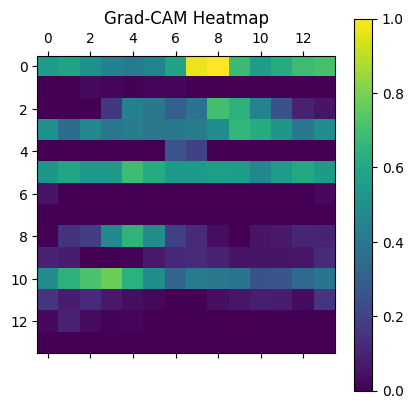

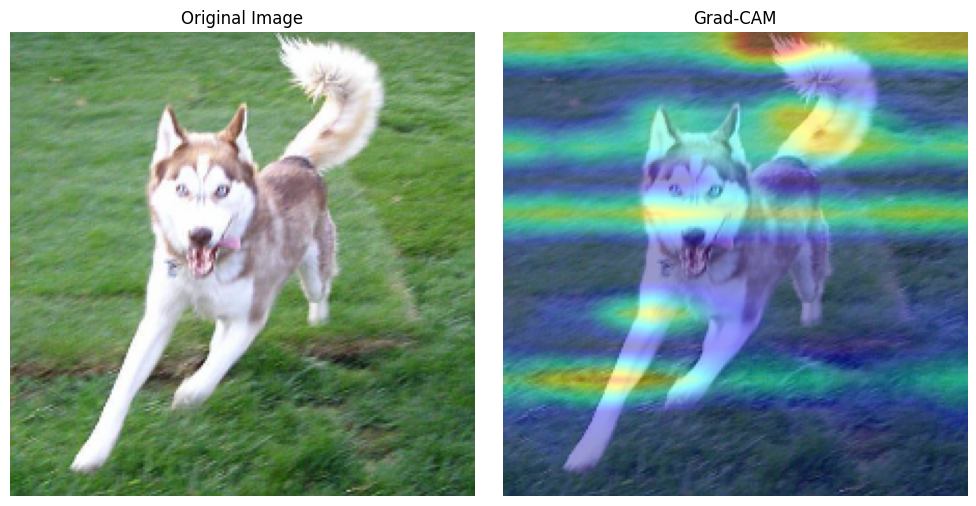

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from keras.utils import load_img, img_to_array

def load_and_preprocess_image(image_path, target_size):
    """
    Load an image from a given path and preprocess it.
    
    Parameters:
    image_path (str): The path to the image file.
    target_size (tuple): The target size for resizing the image (height, width).
    
    Returns:
    np.ndarray: The preprocessed image array normalized to [0, 1].
    """
    img = load_img(image_path, target_size=target_size)  # Load image and resize
    img_array = img_to_array(img)  # Convert image to array format
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array / 255.0  # Normalize pixel values to [0, 1]

def generate_gradcam_heatmap(image_array, model, last_conv_layer_name, predicted_class_index=None):
    """
    Generate a Grad-CAM heatmap for a given image and model.
    
    Parameters:
    image_array (np.ndarray): The preprocessed image array.
    model (tf.keras.Model): The trained model to use for predictions.
    last_conv_layer_name (str): The name of the last convolutional layer in the model.
    predicted_class_index (int, optional): The index of the predicted class to visualize. 
                                            If None, uses the highest predicted class.
    
    Returns:
    np.ndarray: The generated heatmap.
    """
    # Create a model that maps the input image to the output predictions and last conv layer output
    gradient_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Use a gradient tape to record operations for automatic differentiation
    with tf.GradientTape() as tape:
        last_conv_layer_output, predictions = gradient_model(image_array)

        # Check if predictions is a list and access the first element if so
        if isinstance(predictions, list):
            predictions = predictions[0]

        # If predicted_class_index is not provided, get the index of the highest predicted class
        if predicted_class_index is None:
            predicted_class_index = tf.argmax(predictions[0])

        class_channel = predictions[:, predicted_class_index]  # Get the output for the specified class

    # Compute gradients of the class channel with respect to the last conv layer output
    gradients = tape.gradient(class_channel, last_conv_layer_output)

    # Check gradients shape; raise error if None
    if gradients is None:
        raise ValueError("Gradients are None. Check if the layer is trainable.")

    # Pool the gradients by averaging
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1))

    # Get the output of the last convolutional layer
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_gradients[..., tf.newaxis]  # Calculate the heatmap
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU activation to the heatmap
    heatmap = tf.maximum(heatmap, 0)

    # Normalize the heatmap to the range [0, 1]
    heatmap /= tf.math.reduce_max(heatmap) if tf.math.reduce_max(heatmap) > 0 else 1

    return heatmap.numpy()  # Return the heatmap as a numpy array

# Load and preprocess an image
image_path = 'dog.686.jpg'  # Specify the path to the image
target_size = (224, 224)  # Define the target size for the model
image_array = load_and_preprocess_image(image_path, target_size=target_size)  # Load and preprocess the image

# Load the trained model
trained_model = tf.keras.models.load_model('cats_vs_dogs_model_2.h5')

# Print the names of the model layers to find the last convolutional layer
for layer in trained_model.layers:
    print(layer.name)

# Set the name of the last convolutional layer to be used for Grad-CAM
last_conv_layer_name = 'block5_conv3'  # Adjust according to your model's architecture

# Generate the Grad-CAM heatmap for the input image
heatmap = generate_gradcam_heatmap(image_array, trained_model, last_conv_layer_name)

# Display the heatmap
plt.matshow(heatmap)
plt.title("Grad-CAM Heatmap")  # Title for the heatmap display
plt.colorbar()  # Show color scale
plt.show()  # Render the heatmap

# Superimpose the heatmap on the original image
original_image = cv2.imread(image_path)  # Read the original image using OpenCV
original_image = cv2.resize(original_image, target_size)  # Resize to match the model input size
heatmap = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))  # Resize heatmap to image size
heatmap = np.uint8(255 * heatmap)  # Scale heatmap to [0, 255]
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)  # Apply color mapping to heatmap

# Adjust the overlay opacity for better visualization
superimposed_image = heatmap * 0.4 + original_image * 0.6  # Combine heatmap and original image

# Convert to uint8 for display
superimposed_image = np.uint8(superimposed_image)

# Display the original image and the Grad-CAM visualization side by side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
plt.title("Original Image")  # Title for the original image
plt.axis('off')  # Turn off axis labels

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(superimposed_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB
plt.title("Grad-CAM")  # Title for the Grad-CAM image
plt.axis('off')  # Turn off axis labels

plt.tight_layout()  # Adjust layout
plt.show()  # Render the combined image
